In [114]:
import json
import numpy as np
import nltk
from nltk.stem import WordNetLemmatizer
import pickle
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Data Loading and Preprocessing

In [115]:
# Load intents
with open('intents.json') as file:
    intents = json.load(file)

words = []
classes = []
documents = []
ignore_letters = ['?', '!', '.', ',']

# Preprocess intents
for intent in intents['intents']:
    for pattern in intent['patterns']:
        # Tokenize each word
        word_list = nltk.word_tokenize(pattern)
        words.extend(word_list)
        # Add to documents in our corpus
        documents.append((word_list, intent['tag']))
        # Add to our classes list
        if intent['tag'] not in classes:
            classes.append(intent['tag'])

# Lemmatize and lower each word and remove duplicates
words = [lemmatizer.lemmatize(w.lower()) for w in words if w not in ignore_letters]
words = sorted(list(set(words)))

# Sort classes
classes = sorted(list(set(classes)))

print(f"Loaded {len(documents)} documents")
print(f"Classes: {len(classes)}")
print(f"Unique lemmatized words: {len(words)}")

# Save words and classes for later use in the Flask app
pickle.dump(words, open('words.pkl', 'wb'))
pickle.dump(classes, open('classes.pkl', 'wb'))

Loaded 197 documents
Classes: 51
Unique lemmatized words: 139


## 2. Feature Engineering

In [116]:
# Create training data
training = []
output_empty = [0] * len(classes)

for doc in documents:
    bag = []
    word_patterns = doc[0]
    word_patterns = [lemmatizer.lemmatize(word.lower()) for word in word_patterns]
    for word in words:
        bag.append(1) if word in word_patterns else bag.append(0)

    output_row = list(output_empty)
    output_row[classes.index(doc[1])] = 1
    training.append([bag, output_row])

# Shuffle training data
random.shuffle(training)

# Separate features and labels
train_x = np.array([item[0] for item in training])
train_y = np.array([item[1] for item in training])

print(f"Training data shape: X={train_x.shape}, y={train_y.shape}")

Training data shape: X=(197, 139), y=(197, 51)


## 3. Deep Learning Model Building

In [117]:
# Build the model
model = Sequential()
model.add(Dense(256, input_shape=(len(train_x[0]),), activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))


model.add(Dense(len(train_y[0]), activation='softmax'))

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 51)             │         1,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,051 (218.95 KB)

 Trainable params: 56,051 (218.95 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training

In [118]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
# early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# Train model
hist = model.fit(train_x, train_y, epochs=200, batch_size=5, verbose=1, validation_split=0.1)

# Save model
model.save('chatbot_model.h5')
print("Model created and saved to chatbot_model.h5")

Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0282 - loss: 3.9467 - val_accuracy: 0.0000e+00 - val_loss: 3.9152
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0565 - loss: 3.9111 - val_accuracy: 0.0500 - val_loss: 3.8988
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1017 - loss: 3.8435 - val_accuracy: 0.0500 - val_loss: 3.8810
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0904 - loss: 3.7420 - val_accuracy: 0.0500 - val_loss: 3.8565
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1130 - loss: 3.6280 - val_accuracy: 0.1000 - val_loss: 3.7880
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1751 - loss: 3.4290 - val_accuracy: 0.1500 - val_loss: 3.6811
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2034 - loss: 3.0624 - val_accuracy: 0.2500 - val_loss: 3.5382
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2994 - loss: 2.8482 - val_accuracy: 0.2000

Model created and saved to chatbot_model.h5


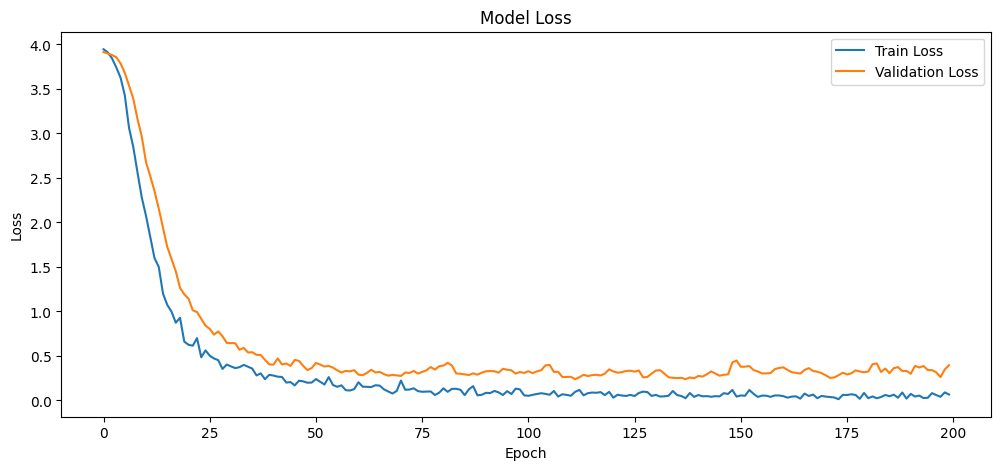

In [119]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.show()

In [120]:
def clean_up_sentence(sentence):
    sentence_words = nltk.word_tokenize(sentence)
    sentence_words = [lemmatizer.lemmatize(word.lower()) for word in sentence_words]

    return sentence_words

In [121]:
def bow(sentence, words, show_details=True):
    sentence_words = clean_up_sentence(sentence)

    bag = [0] * len(words)
    for s in sentence_words:
        for i, w in enumerate(words):
            if w == s:
                bag[i] = 1
                if show_details:
                    print ("found in bag: %s" % w)

    return(np.array(bag))

In [122]:
def predict_class(sentence, model):
    p = bow(sentence, words,show_details=False)
    res = model.predict(np.array([p]))[0]
    ERROR_THRESHOLD = 0.25
    results = [[i, r] for i, r in enumerate(res) if r > ERROR_THRESHOLD]

    results.sort(key=lambda x: x[1], reverse=True)
    return_list = []
    for r in results:
        return_list.append({"intent": classes[r[0]], "probability": str(r[1])})

    return return_list

In [123]:
def getResponse(ints, intents_json):
    tag = ints[0]['intent']
    list_of_intents = intents_json['intents']
    for i in list_of_intents:
        if(i['tag']== tag):
            result = random.choice(i['responses'])
            break

    return result

In [124]:
def chatbot_response(msg):
    ints = predict_class(msg, model)
    res = getResponse(ints, intents)
    return res

In [125]:
chatbot_response('Recommend a book in History')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


{'Book': 'Sex with the Queen',
 'Feedback': "In this follow-up to her bestselling Sex with Kings, Eleanor Herman reveals the truth about what goes on behind the closed door of a queen's boudoir. Impeccably researched, filled with page-turning romance, passion, and scandal, Sex with the Queen explores the scintillating sexual lives of some of our most beloved and infamous female rulers. She was the queen, living in an opulent palace, wearing lavish gowns and dazzling jewels. She was envied, admired, and revered. She was also miserable, having been forced to marry a foreign prince sight unseen, a royal ogre who was sadistic, foaming at the mouth, physically repulsive, mentally incompetent, or sexually impotent—and in some cases all of the above. How did queens find happiness? In courts bristling with testosterone—swashbuckling generals, polished courtiers, and virile cardinals—many royal women had love affairs. Anne Boleyn flirted with courtiers; Catherine Howard slept with one. Henry VI